# Real World Classification

## Load data

Import the necessary libraries

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_selection import r_regression

seed=40
np.random.seed(seed)

load the data

In [3]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # MODIFIED: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    # Find columns with missing values
    missing_cols = df[feature_cols].columns[df[feature_cols].isna().any()]

    # BEFORE imputation
    before_stats = df[missing_cols].agg(['median', 'std'])
    print("======== Before Imputation ========")
    print(before_stats)

    # perform KNN imputation
    impute = KNNImputer(n_neighbors=5)
    df[feature_cols] = impute.fit_transform(df[feature_cols])
    # clip the values to be non-negative
    # df[feature_cols] = df[feature_cols].clip(lower=0)
    
    # AFTER imputation
    after_stats = df[missing_cols].agg(['median', 'std'])
    print("\n\n======== After Imputation ========")
    print(after_stats)
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

======== Before Imputation ========
        SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  BranchLength
median       6.300000      2.900000       5.085612      1.600000     16.300000
std          1.037115      0.389564       1.582807      0.706689      1.035228


======== After Imputation ========
        SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  BranchLength
median       6.300000      2.900000       5.035683      1.700000     16.300000
std          1.009275      0.372434       1.514955      0.694645      1.011012


In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

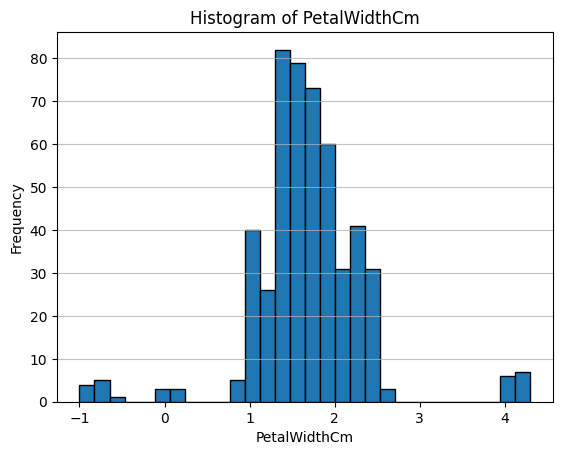

Correlation values:
 PetalWidthCompactness    0.991670
PetalWidthElongation     0.991551
PetalWidthCurvature      0.991273
PetalWidthMajorAxis      0.991141
PetalWidthSpread         0.991095
                           ...   
SepalWidthMinorAxis     -0.074392
SepalWidthCurvature     -0.081334
SepalWidthCompactness   -0.088496
SepalGlossIndex         -0.095200
SepalWidthMajorAxis     -0.096350
Length: 69, dtype: float64

The feature with the largest positive correlation with PetalWidthCm is: PetalWidthCompactness
======== top 5 most negatively correlated features with PetalWidthCm ========
SepalWidthMajorAxis     -0.096350
SepalGlossIndex         -0.095200
SepalWidthCompactness   -0.088496
SepalWidthCurvature     -0.081334
SepalWidthMinorAxis     -0.074392
dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_16732\3105905833.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df[selected_features], labels=selected_features)


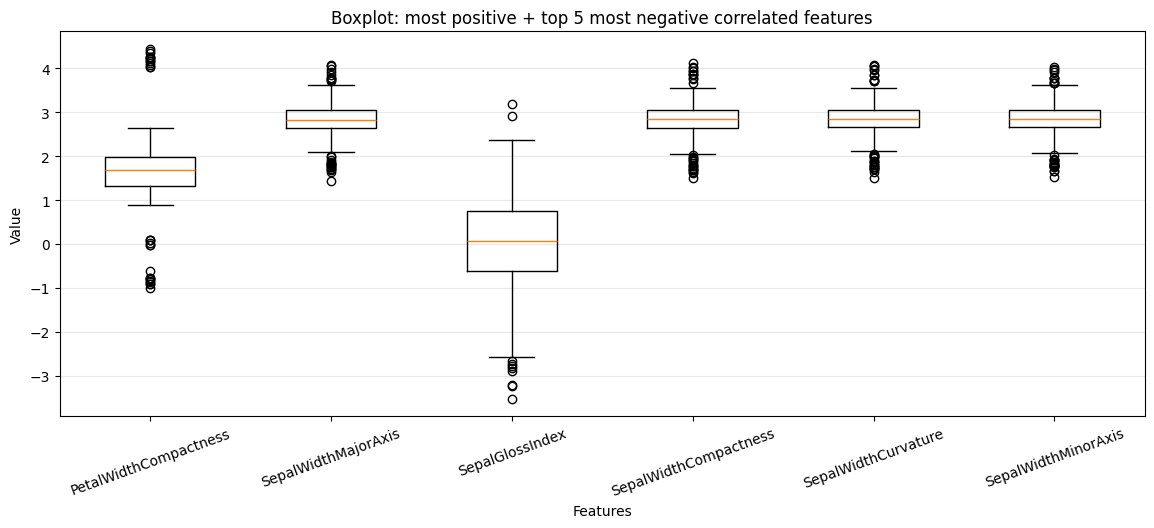

In [6]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration
# (a) plot histogram of the column "PetalWidthCm" 
plt.hist(df['PetalWidthCm'], bins=30, edgecolor='black')
plt.title('Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# list the feature (excluding petalWidthCm, species and id) that has the largest positive correlation (Pearson correlation) with "PetalWidthCm"

# Define features and target
X = df.drop(columns=['PetalWidthCm', 'Species', 'Id'], errors='ignore')
y = df['PetalWidthCm']

# Compute Pearson correlations
r_values = r_regression(X, y)

# Convert to Series for easy handling
correlation = pd.Series(r_values, index=X.columns)

# Get feature with largest positive correlation
most_positive_corr_feature = correlation.idxmax()

print("Correlation values:\n", correlation.sort_values(ascending=False))
print(f"\nThe feature with the largest positive correlation with PetalWidthCm is: {most_positive_corr_feature}")

print("======== top 5 most negatively correlated features with PetalWidthCm ========")
neg_features = correlation.sort_values().head(5).index
print(correlation.sort_values().head(5))

# Single boxplot with 6 features: 1 most positive + top 5 most negative
selected_features = [most_positive_corr_feature] + [f for f in neg_features if f != most_positive_corr_feature]

plt.figure(figsize=(14, 5))
plt.boxplot(df[selected_features], labels=selected_features)
plt.title('Boxplot: most positive + top 5 most negative correlated features')
plt.xlabel('Features')
plt.ylabel('Value')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
plt.show()

## Model Training

### Prepare the data

In [7]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

In [8]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
from model.metrics import evaluate_binary_classifier

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)

def train_model(df, lr=0.1, reg_type = '', reg_lambda=0.0):
    np.random.seed(seed)

    X = df[feature_cols].values.astype(float)
    y = df['Species'].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
    
    model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
    model.fit(X_train, y_train, lr=lr, n_iteration =10000, val_ratio=0.2, reg_type=reg_type, reg_lambda=reg_lambda)
    # print model parameters
    print("Model parameters (weights):", model.W)
    # sum of absolute values of weights
    print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))
    y_pred = model.predict(X_test)
    evaluate_binary_classifier(y_test, y_pred)

### No Regularization

50. Training loss: 0.6572950512169217, Val loss:0.6699856821878871
100. Training loss: 0.6226307711490021, Val loss:0.6436636316717125
150. Training loss: 0.5968536106438317, Val loss:0.6248019734101418
200. Training loss: 0.5770724410855091, Val loss:0.6109725987973054
250. Training loss: 0.5614500987624708, Val loss:0.6006341363275265
300. Training loss: 0.5488013196405573, Val loss:0.5927862551965061
350. Training loss: 0.5383413721955611, Val loss:0.5867610521735693
400. Training loss: 0.5295356518896497, Val loss:0.5820996162672264
450. Training loss: 0.5220096572557988, Val loss:0.5784781297261021
500. Training loss: 0.51549415543084, Val loss:0.5756625817533594
550. Training loss: 0.5097909798441069, Val loss:0.573480262206977
600. Training loss: 0.5047511496548615, Val loss:0.5718013280805994
650. Training loss: 0.5002605183372977, Val loss:0.5705265741611237
700. Training loss: 0.49623013467643184, Val loss:0.5695791245134203
750. Training loss: 0.49258962365573294, Val loss:0

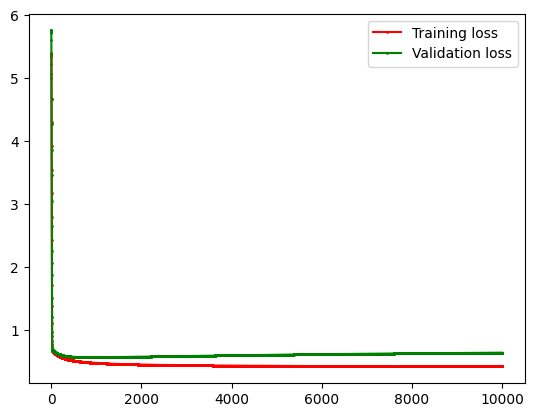

Model parameters (weights): [[-3.16335176]
 [ 1.08853101]
 [ 0.71350466]
 [-0.8911023 ]
 [ 1.66226609]
 [ 0.5786216 ]
 [ 0.3065608 ]
 [-0.22656249]
 [ 0.60023229]
 [ 1.34775177]
 [ 1.12105697]
 [ 0.13582979]
 [ 0.91532985]
 [-0.25514498]
 [-1.06000782]
 [ 0.02580588]
 [ 1.29641721]
 [ 0.46583142]
 [ 0.708017  ]
 [-0.36421518]
 [ 1.03551315]
 [ 0.91255039]
 [-0.28515676]
 [ 0.96740435]
 [-0.2501886 ]
 [ 1.86846412]
 [ 1.65606493]
 [ 1.427259  ]
 [ 1.94460281]
 [ 2.01542746]
 [ 1.41402383]
 [-2.26918045]
 [ 1.53705993]
 [-0.36344481]
 [ 0.19244885]
 [-1.44748147]
 [ 0.70819491]
 [-1.04435298]
 [-2.97198857]
 [-0.42692794]
 [-1.24261354]
 [-0.41796296]
 [-0.98414705]
 [-1.22924233]
 [ 0.50058516]
 [-0.04456719]
 [ 0.02405468]
 [ 0.32226938]
 [-0.64850895]
 [-0.66593166]
 [-0.48056443]
 [ 0.32707679]
 [ 0.17495455]
 [-0.61593367]
 [-0.36535728]
 [ 0.49267489]
 [-0.85987899]
 [-1.26373002]
 [-0.28735217]
 [ 0.57001036]
 [-1.02409882]
 [ 0.71907016]
 [ 0.6272286 ]
 [-1.5667075 ]
 [ 0.1079384

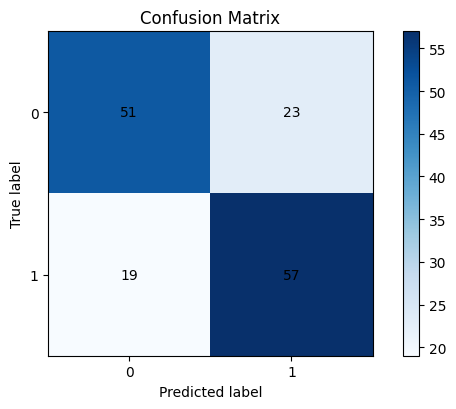

In [9]:
train_model(df, reg_type=None, reg_lambda=0.0)

### L2 Reg = 0.01

50. Training loss: 0.6572929744907086, Val loss:0.6699828194400217
100. Training loss: 0.6226370708593969, Val loss:0.6436662386803186
150. Training loss: 0.5968724567755489, Val loss:0.6248125819822072
200. Training loss: 0.57710513261878, Val loss:0.6109911766151703
250. Training loss: 0.5614967431436563, Val loss:0.6006595362014496
300. Training loss: 0.5488615550371709, Val loss:0.592816880200311
350. Training loss: 0.5384146721109383, Val loss:0.5867951648523863
400. Training loss: 0.5296214516465223, Val loss:0.5821354839154357
450. Training loss: 0.5221074045422048, Val loss:0.5785140918733358
500. Training loss: 0.5156033285344713, Val loss:0.575697079625259
550. Training loss: 0.5099110923718569, Val loss:0.5735118491814875
600. Training loss: 0.5048817498726622, Val loss:0.5718286705532784
650. Training loss: 0.5004011866212236, Val loss:0.5705484476177355
700. Training loss: 0.4963804805267807, Val loss:0.5695944073134431
750. Training loss: 0.4927492828335417, Val loss:0.56

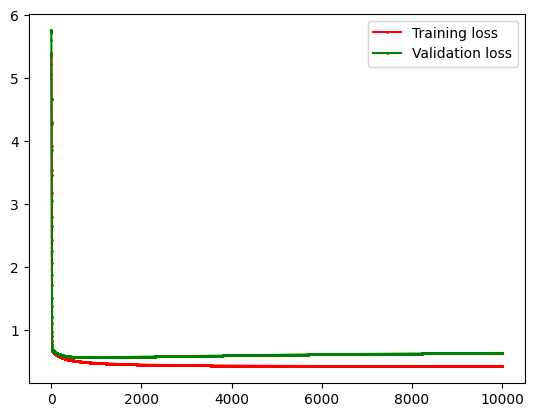

Model parameters (weights): [[-3.04491277]
 [ 1.06690025]
 [ 0.6919335 ]
 [-0.85765019]
 [ 1.62211418]
 [ 0.56005118]
 [ 0.30158619]
 [-0.19463749]
 [ 0.57958933]
 [ 1.32752235]
 [ 1.08574484]
 [ 0.15657535]
 [ 0.90839498]
 [-0.23907741]
 [-1.02912786]
 [ 0.03492654]
 [ 1.25176991]
 [ 0.46155106]
 [ 0.67736629]
 [-0.3360695 ]
 [ 0.99104444]
 [ 0.88548156]
 [-0.25831271]
 [ 0.92720969]
 [-0.2240548 ]
 [ 1.83330247]
 [ 1.63715657]
 [ 1.42059956]
 [ 1.90523001]
 [ 1.97682052]
 [ 1.40626307]
 [-2.21460197]
 [ 1.49055105]
 [-0.3597555 ]
 [ 0.18556675]
 [-1.40617771]
 [ 0.68446346]
 [-1.02786244]
 [-2.91241716]
 [-0.42070369]
 [-1.21899384]
 [-0.41412216]
 [-0.97368391]
 [-1.20316405]
 [ 0.48756144]
 [-0.06099954]
 [ 0.01549635]
 [ 0.30103751]
 [-0.63725608]
 [-0.65781288]
 [-0.47183837]
 [ 0.3066131 ]
 [ 0.16544312]
 [-0.60674983]
 [-0.35497642]
 [ 0.47752786]
 [-0.84634486]
 [-1.24388514]
 [-0.28766676]
 [ 0.53941665]
 [-1.00871619]
 [ 0.69605025]
 [ 0.60968265]
 [-1.54064268]
 [ 0.0956521

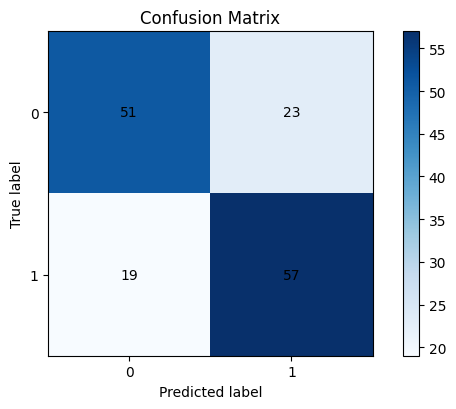

In [10]:
train_model(df, reg_type="l2", reg_lambda=0.01)

### L2 Reg = 1

50. Training loss: 0.6571098767748111, Val loss:0.6697244267768969
100. Training loss: 0.6233246012236595, Val loss:0.643999865252734
150. Training loss: 0.5988483414837363, Val loss:0.6260046211970154
200. Training loss: 0.580503081098561, Val loss:0.6130584747744167
250. Training loss: 0.5663340514385814, Val loss:0.6035153895899893
300. Training loss: 0.555109610778399, Val loss:0.5963362172188005
350. Training loss: 0.5460282664733441, Val loss:0.5908438177965458
400. Training loss: 0.5385508819400877, Val loss:0.5865832541498986
450. Training loss: 0.5323033478328502, Val loss:0.5832403037115937
500. Training loss: 0.5270186638253865, Val loss:0.5805925757006578
550. Training loss: 0.5225014437416007, Val loss:0.5784792861358805
600. Training loss: 0.5186055098416564, Val loss:0.5767820163311911
650. Training loss: 0.5152193449448941, Val loss:0.5754121279039556
700. Training loss: 0.5122563954812427, Val loss:0.5743023265172252
750. Training loss: 0.5096484503192897, Val loss:0.5

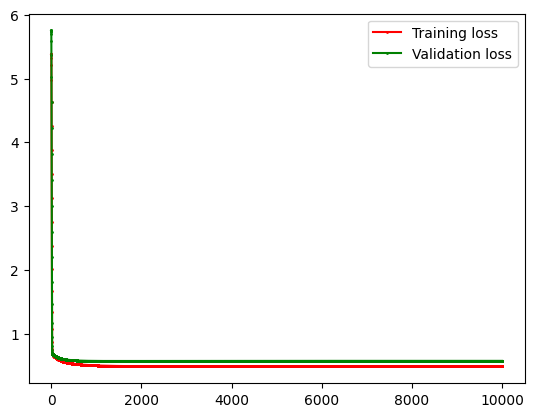

Model parameters (weights): [[-0.67367191]
 [ 0.48871783]
 [ 0.17973896]
 [-0.01441526]
 [ 0.80396647]
 [ 0.31703553]
 [ 0.20008657]
 [ 0.28810773]
 [ 0.33015999]
 [ 0.52360076]
 [ 0.40323486]
 [ 0.3778058 ]
 [ 0.47881443]
 [ 0.02756468]
 [-0.14442614]
 [ 0.10543009]
 [ 0.24329265]
 [ 0.19115282]
 [ 0.1390483 ]
 [ 0.13118977]
 [ 0.22693633]
 [ 0.27872029]
 [ 0.15166806]
 [ 0.2457706 ]
 [ 0.16492078]
 [ 0.85276969]
 [ 0.86812361]
 [ 0.87351467]
 [ 0.88922733]
 [ 0.91021254]
 [ 0.87363237]
 [-0.71611664]
 [ 0.33688178]
 [-0.22246374]
 [-0.00511053]
 [-0.36642025]
 [ 0.08091502]
 [-0.45786534]
 [-1.16838721]
 [-0.18598461]
 [-0.50218181]
 [-0.21872289]
 [-0.56237102]
 [-0.43937779]
 [ 0.10080916]
 [-0.24072984]
 [-0.17200626]
 [-0.13673927]
 [-0.34469301]
 [-0.35869966]
 [-0.21152161]
 [-0.11001394]
 [-0.08477857]
 [-0.30106673]
 [-0.12436427]
 [ 0.05426756]
 [-0.41636498]
 [-0.58113397]
 [-0.24636433]
 [-0.08876187]
 [-0.55101483]
 [ 0.10698488]
 [ 0.17934474]
 [-0.6301461 ]
 [-0.1842545

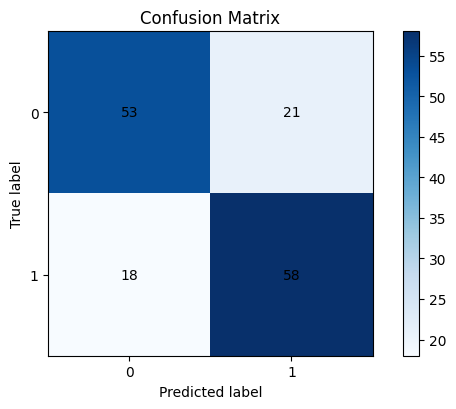

In [11]:
train_model(df, reg_type="l2", reg_lambda=1)

### L2 Reg = 100

50. Training loss: 0.6750694290943433, Val loss:0.6840309642470094
100. Training loss: 0.6747548127534178, Val loss:0.6839309748933531
150. Training loss: 0.6747488372001222, Val loss:0.6839298599003173
200. Training loss: 0.6747487203171995, Val loss:0.6839298551190556
250. Training loss: 0.6747487180286232, Val loss:0.6839298554515596
300. Training loss: 0.6747487179838312, Val loss:0.6839298554687433
350. Training loss: 0.6747487179829557, Val loss:0.6839298554693461
400. Training loss: 0.6747487179829386, Val loss:0.6839298554693646
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
750. Training loss: 0.6747487179829382, Val loss:0

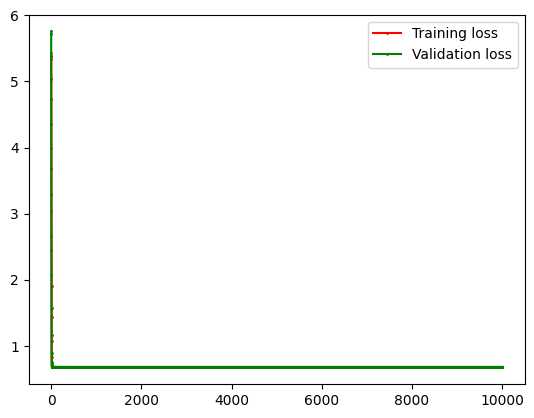

Model parameters (weights): [[-0.01249206]
 [ 0.02228109]
 [ 0.00731174]
 [ 0.02160094]
 [ 0.03647292]
 [ 0.01868654]
 [ 0.01769178]
 [ 0.01789019]
 [ 0.01923883]
 [ 0.02027882]
 [ 0.01914643]
 [ 0.02013799]
 [ 0.02095232]
 [ 0.00458568]
 [ 0.00311998]
 [ 0.00605684]
 [ 0.00705284]
 [ 0.00742952]
 [ 0.00627274]
 [ 0.02328098]
 [ 0.02385686]
 [ 0.02565637]
 [ 0.02391417]
 [ 0.02520387]
 [ 0.02375411]
 [ 0.03462815]
 [ 0.03522777]
 [ 0.03662822]
 [ 0.03649798]
 [ 0.036714  ]
 [ 0.03671077]
 [-0.01304758]
 [ 0.00456383]
 [-0.00644573]
 [-0.00238571]
 [-0.00519696]
 [-0.00335385]
 [-0.0124363 ]
 [-0.02754184]
 [-0.00523545]
 [-0.00983527]
 [-0.0041134 ]
 [-0.01539004]
 [-0.00700335]
 [-0.0017571 ]
 [-0.00552268]
 [-0.00863107]
 [-0.00523874]
 [-0.01145154]
 [-0.00881981]
 [-0.00133932]
 [-0.00757033]
 [-0.00632656]
 [-0.0080036 ]
 [-0.00210421]
 [-0.00160616]
 [-0.00839356]
 [-0.01317914]
 [-0.00861225]
 [-0.01061584]
 [-0.01525315]
 [-0.00042755]
 [ 0.00442472]
 [-0.01255564]
 [-0.0094437

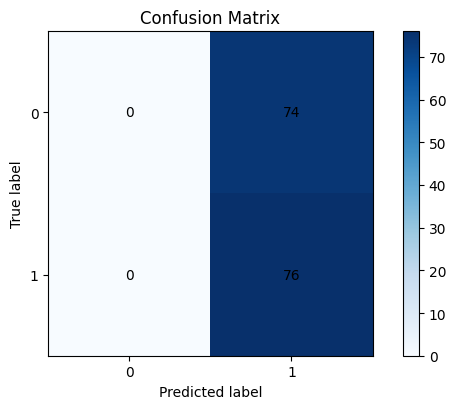

In [12]:
train_model(df, reg_type="l2", reg_lambda=100)

## 1(a). K-fold Cross-Validation

In [24]:
from sklearn.model_selection import KFold, cross_val_score
from model.linear_model import LinearModel
from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid
import pandas as pd
import numpy as np

lrs = [0.005, 0.01, 0.1, 0.5]
reg_lambdas = [1.0, 2.0, 4.0, 8.0]
seed = 40

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

results = np.zeros((len(lrs), len(reg_lambdas)))

cv = KFold(n_splits=5, shuffle=True, random_state=40)

# Make sure X_train and y_train are available and in correct shape, 
# which they should be after running the 'Prepare the data' cell.
for i, lr in enumerate(lrs):
    for j, reg_lambda in enumerate(reg_lambdas):
        model = LinearModel(dim=X_train.shape[1], 
                            is_reg=False, 
                            loss_fn=loss_fn, 
                            act_fn=act_fn, 
                            grad_fn=grad_fn,
                            lr=lr, 
                            n_iteration = 10000,
                            val_ratio=0.2,
                            reg_type='l2', 
                            reg_lambda=reg_lambda,
                            random_state=seed,
                            verbose=False, 
                            plot_curve=False)
        
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
        results[i, j] = scores.mean()

# Present the results in a 4x4 matrix
results_df = pd.DataFrame(results, index=[f"lr={lr}" for lr in lrs], columns=[f"lambda={lam}" for lam in reg_lambdas])
print("5-fold CV Average Accuracy:")
display(results_df)

# Find top two combinations
flat_indices = np.argsort(results.flatten())[::-1]
top2_indices = flat_indices[:2]
top2_params = []
print("\nTop 2 Hyperparameter Settings:")
for idx in top2_indices:
    lr_idx = idx // len(reg_lambdas)
    lam_idx = idx % len(reg_lambdas)
    top2_params.append((lrs[lr_idx], reg_lambdas[lam_idx]))
    print(f"Learning Rate: {lrs[lr_idx]}, reg_lambda: {reg_lambdas[lam_idx]} (Accuracy: {results[lr_idx, lam_idx]:.4f})")


5-fold CV Average Accuracy:


,lambda=1.0,lambda=2.0,lambda=4.0,lambda=8.0
lr=0.005,0.717143,0.720000,0.725714,0.722857
lr=0.01,0.722857,0.728571,0.725714,0.717143
lr=0.1,0.722857,0.725714,0.725714,0.717143
lr=0.5,0.722857,0.691429,0.534286,0.465714



Top 2 Hyperparameter Settings:
Learning Rate: 0.01, reg_lambda: 2.0 (Accuracy: 0.7286)
Learning Rate: 0.1, reg_lambda: 2.0 (Accuracy: 0.7257)


## 1(b). Top Two Models Evaluation

=== Rank 1 Model: lr=0.01, reg_lambda=2.0 ===
Model Evaluation
Accuracy  : 0.7600
Precision : 0.7381
Recall    : 0.8158
F1-score  : 0.7750
Model Evaluation
Accuracy  : 0.7600
Precision : 0.7381
Recall    : 0.8158
F1-score  : 0.7750


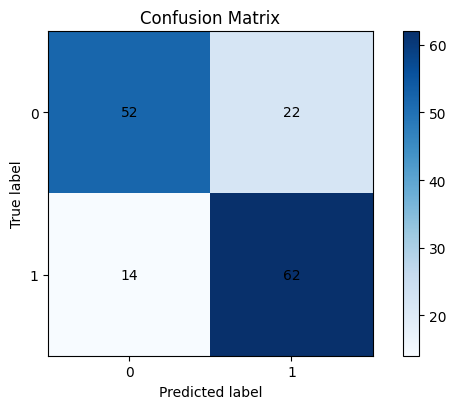



=== Rank 2 Model: lr=0.1, reg_lambda=2.0 ===
Model Evaluation
Accuracy  : 0.7533
Precision : 0.7294
Recall    : 0.8158
F1-score  : 0.7702
Model Evaluation
Accuracy  : 0.7533
Precision : 0.7294
Recall    : 0.8158
F1-score  : 0.7702


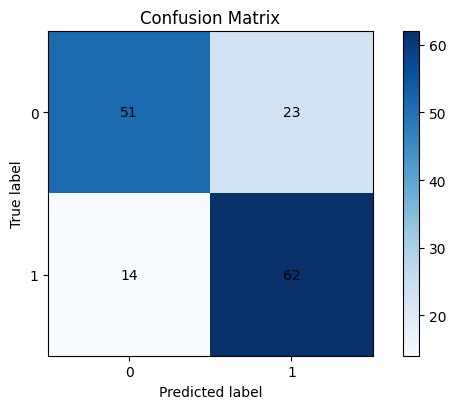

In [25]:
from model.metrics import evaluate_binary_classifier

# Evaluate top two models on test set
for rank, (lr, reg_lambda) in enumerate(top2_params, 1):
    print(f"=== Rank {rank} Model: lr={lr}, reg_lambda={reg_lambda} ===")
    
    # Instantiate model with optimal parameters
    np.random.seed(seed) # Ensure consistent weights initialization
    best_model = LinearModel(dim=X_train.shape[1], 
                            is_reg=False, 
                            loss_fn=loss_fn, 
                            act_fn=act_fn, 
                            grad_fn=grad_fn,
                            lr=lr, 
                            n_iteration = 10000,
                            val_ratio=0.2,
                            reg_type='l2', 
                            reg_lambda=reg_lambda,
                            random_state=seed,
                            verbose=False, 
                            plot_curve=False)
    
    # Train on full training data
    best_model.fit(X_train, y_train, lr=lr)
    
    # Predict on test data
    y_pred = best_model.predict(X_test)
    
    # Evaluate
    evaluate_binary_classifier(y_test, y_pred)
    print("\n")


## 1(c). Observations

**Observations from 1(a):**
* (Fill in your observations on how changing the learning rate and regularization parameter affected the average accuracy on the validation folds.)

**Observations from 1(b):**
* (Fill in your observations from the final testing results of the top two hyperparameter settings. Did the top settings accurately reflect performance on the completely unseen testing set?)